### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.feature_extraction import text
from sklearn.metrics import pairwise

### Step 2: Load Data

In [4]:
df = pd.read_csv('./data/tcc_ceds_music.csv', index_col='Unnamed: 0')

In [5]:
df = df.reset_index()

In [6]:
df.shape

(28372, 31)

In [7]:
df.head()

,index,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.380299,0.117175,0.357739,0.454119,0.997992,0.901822,0.339448,0.137110,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.331745,0.647540,0.954819,0.000002,0.325021,0.263240,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.002770,0.225422,0.456298,0.585288,0.840361,0.000000,0.351814,0.139112,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.225889,0.001548,0.686992,0.744404,0.083935,0.199393,0.775350,0.743736,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.068800,0.001350,0.291671,0.646489,0.975904,0.000246,0.597073,0.394375,romantic,1.0


### Step 3: Exploaring Data

#### Basic Info

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,28372.0,42946.323558,24749.325492,0.000000e+00,20391.250000,45405.500000,64090.500000,82451.000000
release_date,28372.0,1990.236888,18.487463,1.950000e+03,1975.000000,1991.000000,2007.000000,2019.000000
len,28372.0,73.028444,41.829831,1.000000e+00,42.000000,63.000000,93.000000,199.000000
dating,28372.0,0.021112,0.052370,2.907822e-04,0.000923,0.001462,0.004049,0.647706
violence,28372.0,0.118396,0.178684,2.844950e-04,0.001120,0.002506,0.192608,0.981781
world/life,28372.0,0.120973,0.172200,2.907822e-04,0.001170,0.006579,0.197793,0.962105
night/time,28372.0,0.057387,0.111923,2.891845e-04,0.001032,0.001949,0.065842,0.973684
shake the audience,28372.0,0.017422,0.040670,2.844950e-04,0.000993,0.001595,0.010002,0.497463
family/gospel,28372.0,0.017045,0.041966,2.891845e-04,0.000923,0.001504,0.004785,0.545303
romantic,28372.0,0.048681,0.106095,2.844950e-04,0.000975,0.001754,0.042301,0.940789


In [9]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(df.isnull().sum()/len(df), 2),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [10]:
feature_info

,null,null(%),unique,type
index,0,0.0,28372,int64
artist_name,0,0.0,5426,object
track_name,0,0.0,23689,object
release_date,0,0.0,70,int64
genre,0,0.0,7,object
lyrics,0,0.0,28372,object
len,0,0.0,199,int64
dating,0,0.0,27918,float64
violence,0,0.0,28189,float64
world/life,0,0.0,28195,float64


#### Feature Distribution

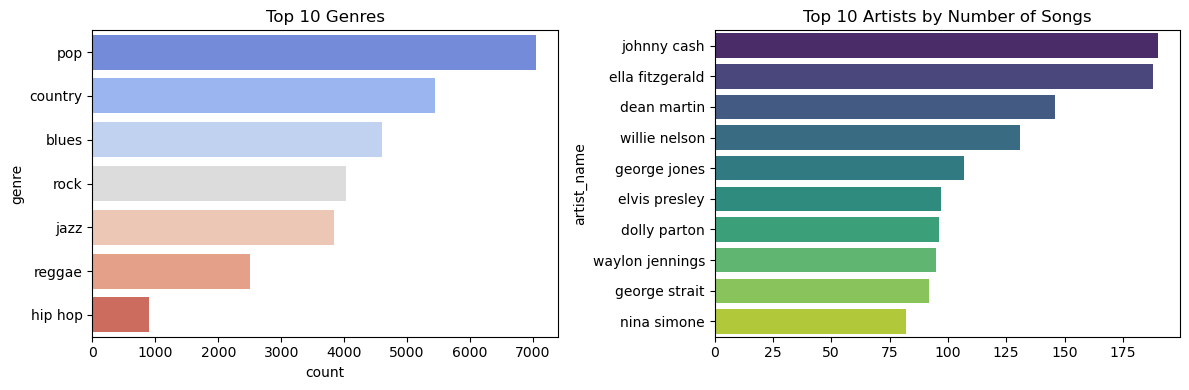

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(y='genre', data=df, palette='coolwarm', order=df['genre'].value_counts().index)
plt.title('Top 10 Genres')
plt.subplot(1, 2, 2)
temp = df.groupby('artist_name').size().sort_values(ascending=False).head(10)
sns.barplot(x=temp.values, y=temp.index, palette='viridis')
plt.title('Top 10 Artists by Number of Songs')
plt.tight_layout()

### Step 4: Preparing Data

#### Vectorize Feature

In [12]:
df['combined_features'] = (df['genre'] + ' ' + df['artist_name'] + ' ' + df['track_name'])

In [13]:
vector = text.TfidfVectorizer(stop_words='english')

In [14]:
vector_matrix = vector.fit_transform(df['combined_features'])

#### Compute Similarity Scores

In [15]:
cos_sim = pairwise.cosine_similarity(vector_matrix)

In [16]:
song_title = 'cry'

In [17]:
idx = df[df['track_name'] == song_title].index

In [77]:
sim_scores = np.argsort(cos_sim[idx], axis=1)[3, -11: -1]

In [78]:
recommendations = df.iloc[np.flip(sim_scores)]

In [79]:
recommendations[['track_name', 'artist_name', 'genre']]

,track_name,artist_name,genre
1208,top of the world,mandy moore,pop
1856,mandy,barry manilow,pop
17264,mandy,rosemary clooney,jazz
14527,out of my system,gary moore,blues
14800,after the war,gary moore,blues
15118,with love (remember),gary moore,blues
14275,falling in love with you,gary moore,blues
14895,too tired,gary moore,blues
14347,hiroshima,gary moore,blues
12162,come and get it,kip moore,country
